# `EDA on Insurance Claim Dataset:`

## `Notebook Overview:`

In this notebook, we will take a closer look at Insurance Claims and figure out some facts about how conditions such as blood pressure, BMI, diabetes, smoking, age, and gender impact the claim value.

We will touch the topics through exploratory data analysis (EDA) using scatter plots, pie charts, histograms etc.

In [2]:
# importing necessary libraries
import numpy as np    # for linear algebra
import pandas as pd   # for reading data files
import matplotlib.pyplot as plt  # for making graphs
%matplotlib inline
import seaborn as sns  # another library for making graphs 

In [3]:
# reading the csv file
df_ins = pd.read_csv('insurance_data.csv')

## `Data Processing and Data Preparation:`

In [4]:
# checking the dataset content
df_ins.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [5]:
# checking the rows and cols of the dataset
rows = df_ins.shape[0]
cols = df_ins.shape[1]
print(f'The insurance claim dataset contains {rows} rows and {cols} cols')


The insurance claim dataset contains 1340 rows and 11 cols


In [6]:
# data types + non-null counts for every column
df_ins.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   str    
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   str    
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   str    
 9   region         1337 non-null   str    
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 115.3 KB


In [7]:
# finding which cols have null values
df_ins.isna().sum()

index            0
PatientID        0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

> This shows the our age col and region col have null values we need to handle them safely.

In [8]:
df = df_ins.copy()

# age (numeric, low skew) → median fill
df['age'] = df['age'].fillna(df['age'].median())

# region (categorical) → mode fill
df['region'] = df['region'].fillna(df['region'].mode()[0])

df.isna().sum()

index            0
PatientID        0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [9]:
# getting a deeper look in the dataset
df.describe().round(0)

,index,PatientID,age,bmi,bloodpressure,children,claim
count,1340.0,1340.0,1340.0,1340.0,1340.0,1340.0,1340.0
mean,670.0,670.0,38.0,31.0,94.0,1.0,13253.0
std,387.0,387.0,11.0,6.0,11.0,1.0,12110.0
min,0.0,1.0,18.0,16.0,80.0,0.0,1122.0
25%,335.0,336.0,29.0,26.0,86.0,0.0,4720.0
50%,670.0,670.0,38.0,30.0,92.0,1.0,9370.0
75%,1004.0,1005.0,47.0,35.0,99.0,2.0,16604.0
max,1339.0,1340.0,60.0,53.0,140.0,5.0,63770.0


In [10]:
# checking for the categorical col and there values in dataset
for col in df.columns:
    if df[col].dtype == 'str':
        print(col)
        print(df[col].unique())
        print()

gender
<StringArray>
['male', 'female']
Length: 2, dtype: str

diabetic
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

smoker
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

region
<StringArray>
['southeast', 'northwest', 'southwest', 'northeast']
Length: 4, dtype: str



In [11]:
# replacing the diabetic and smoker col appropriately using replace for better understanding
df['diabetic'] = df['diabetic'].replace({'Yes': 'diabetic', 'No': 'non-diabetic'})
df['smoker'] = df['smoker'].replace({'Yes': 'smoker', 'No': 'non-smoker'})

In [12]:
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,diabetic,0,non-smoker,southeast,1121.87
1,1,2,24.0,male,30.1,87,non-diabetic,0,non-smoker,southeast,1131.51
2,2,3,38.0,male,33.3,82,diabetic,0,non-smoker,southeast,1135.94
3,3,4,38.0,male,33.7,80,non-diabetic,0,non-smoker,northwest,1136.40
4,4,5,38.0,male,34.1,100,non-diabetic,0,non-smoker,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,diabetic,0,smoker,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,non-diabetic,1,smoker,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,diabetic,3,smoker,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,non-diabetic,0,smoker,southeast,62592.87


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1340 non-null   float64
 3   gender         1340 non-null   str    
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   str    
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   str    
 9   region         1340 non-null   str    
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 115.3 KB


> Every null value is maintained safely and we have a breif overview about the data we are working on.

## `Exploratory Data Analysis (EDA):`

**`Numerical Columns:`**

- age
- bmi
- bloodpressure
- children
- claim

**`Categorical Columns:`**

- gender
- diabetic
- smoker
- region

### `Univariate Analysis:`

#### `Numerical Columns:`

**`1. age:`**

In [14]:
df['age'].describe()

count    1340.000000
mean       38.078358
std        11.082176
min        18.000000
25%        29.000000
50%        38.000000
75%        47.000000
max        60.000000
Name: age, dtype: float64

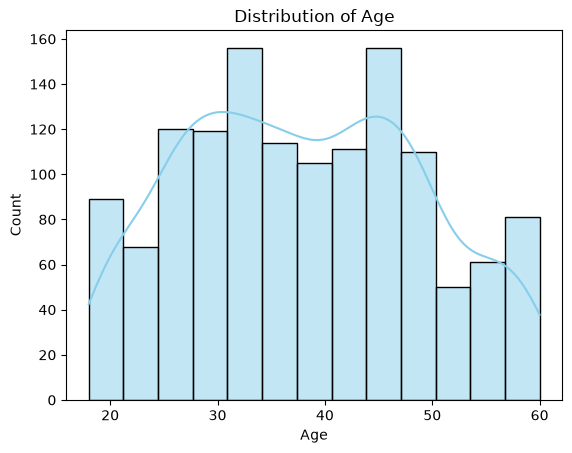

In [34]:
sns.histplot(data=df, x='age', kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

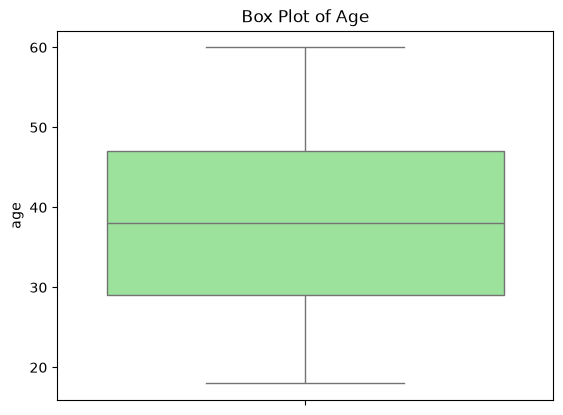

In [31]:
sns.boxplot(data=df, y='age', color='lightgreen')

plt.title('Box Plot of Age')

plt.show()

In [32]:
df['age'].skew()

np.float64(0.11390294679791582)

**Conclusion:**
- The kde shows 2 peaks
- Age is almost rougly symmetrical
- Boxplot shows there is no outlier in the age col

**`2. bmi:`**

In [46]:
df['bmi'].describe()

count    1340.000000
mean       30.668955
std         6.106735
min        16.000000
25%        26.275000
50%        30.400000
75%        34.700000
max        53.100000
Name: bmi, dtype: float64

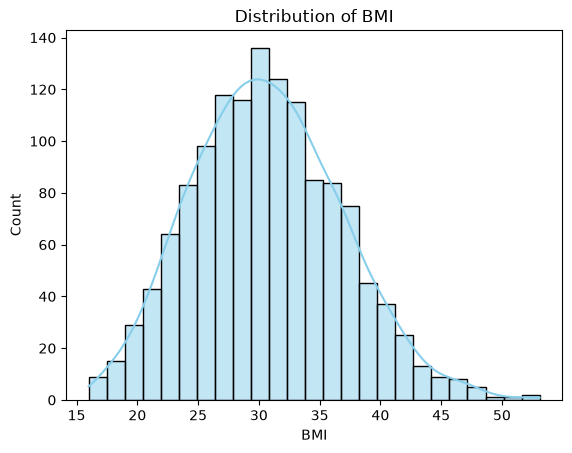

In [45]:
sns.histplot(data=df, x='bmi', kde=True, color='skyblue')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

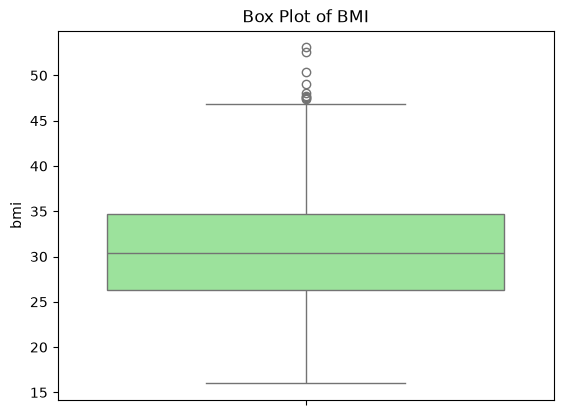

In [47]:
sns.boxplot(data=df, y='bmi', color='lightgreen')

plt.title('Box Plot of BMI')

plt.show()

In [63]:
df[df['bmi'] > 47]

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
9,9,10,30.0,male,53.1,97,non-diabetic,0,non-smoker,northwest,1163.46
141,141,142,46.0,male,50.4,89,diabetic,1,non-smoker,southeast,2438.06
579,579,580,25.0,male,47.5,84,diabetic,1,non-smoker,southeast,8083.92
675,675,676,49.0,female,48.1,81,diabetic,2,non-smoker,northeast,9432.93
696,696,697,49.0,male,47.7,88,non-diabetic,1,non-smoker,southeast,9748.91
802,802,803,42.0,male,49.1,109,diabetic,0,non-smoker,southeast,11381.33
1299,1299,1300,50.0,male,52.6,110,non-diabetic,1,smoker,southeast,44501.40
1306,1306,1307,43.0,female,47.6,112,diabetic,2,smoker,southwest,46113.51
1339,1339,1340,30.0,female,47.4,101,non-diabetic,0,smoker,southeast,63770.43


In [42]:
df['bmi'].skew()

np.float64(0.28597245020808587)

**Conclusion:**
- The bmi kde shows that it is almost normal but there is some stretch in the right side 
- There are outliers in the bmi col as shown in the boxplot these are the people who are obese mostly those people whose bmi is greater then 47. This can be used further to find if it effect the insurance claim when doing bi-variate anaylsis.
- There are 9 patients who will be counted as outliers. 

**`3. bloodpressure:`**

In [52]:
df['bloodpressure'].describe()

count    1340.000000
mean       94.157463
std        11.434712
min        80.000000
25%        86.000000
50%        92.000000
75%        99.000000
max       140.000000
Name: bloodpressure, dtype: float64

iqr = 99 - 86 = 13
13 * 1.5 = 19.5
lb = 86 - 19.5 = 66.5
ub = 99 + 19.5 = 118.5

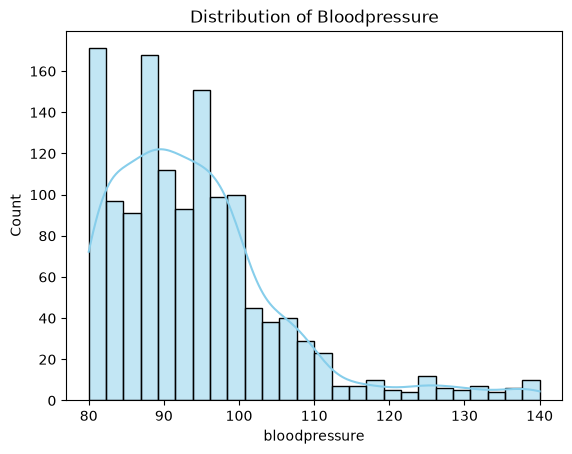

In [51]:
sns.histplot(data=df, x='bloodpressure', kde=True, color='skyblue')
plt.title('Distribution of Bloodpressure')
plt.xlabel('bloodpressure')
plt.ylabel('Count')
plt.show()

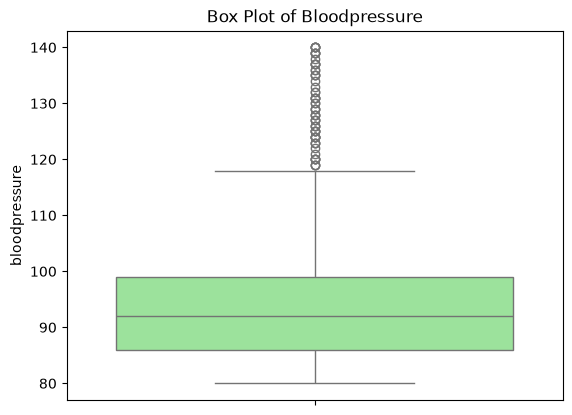

In [50]:
sns.boxplot(data=df, y='bloodpressure', color='lightgreen')

plt.title('Box Plot of Bloodpressure')

plt.show()

In [64]:
df[df['bloodpressure'] > 118.5]

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1147,1147,1148,29.0,female,32.7,128,diabetic,2,non-smoker,northwest,26018.95
1150,1150,1151,55.0,female,27.1,135,non-diabetic,1,non-smoker,southwest,26140.36
1152,1152,1153,38.0,female,35.9,128,non-diabetic,1,non-smoker,northeast,26392.26
1153,1153,1154,43.0,male,36.8,126,non-diabetic,2,non-smoker,northwest,26467.10
1154,1154,1155,31.0,male,23.8,126,diabetic,0,smoker,southeast,26926.51
...,...,...,...,...,...,...,...,...,...,...,...
1325,1325,1326,52.0,female,36.4,133,diabetic,1,smoker,northeast,48517.56
1332,1332,1333,26.0,male,37.0,120,non-diabetic,2,smoker,southeast,49577.66
1333,1333,1334,44.0,male,36.4,127,non-diabetic,1,smoker,southwest,51194.56
1334,1334,1335,43.0,male,32.8,125,non-diabetic,0,smoker,southwest,52590.83


In [49]:
df['bloodpressure'].skew()

np.float64(1.4835342102293079)

**Conclusions:**
- The kde plot shows that bloodpressure is strongly right skewed.
- The boxplot represents the data contains outliers. This show there are some peoples with high bp any bp value above 118.5 is outlier. There are 62 patients rougly that are forming outlier cluster

**`4. children:`**

In [54]:
df['children'].describe()

count    1340.000000
mean        1.093284
std         1.205334
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

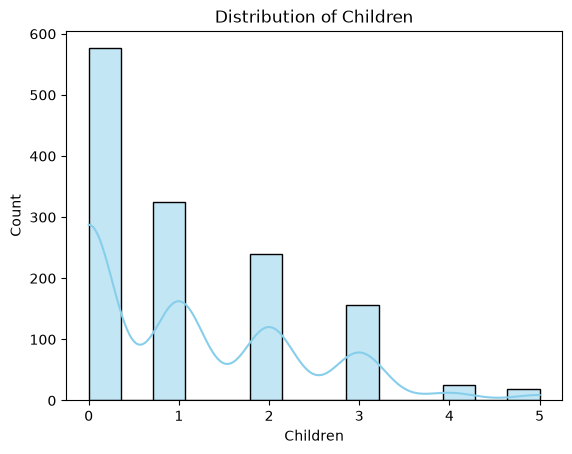

In [55]:
sns.histplot(data=df, x='children', kde=True, color='skyblue')
plt.title('Distribution of Children')
plt.xlabel('Children')
plt.ylabel('Count')
plt.show()

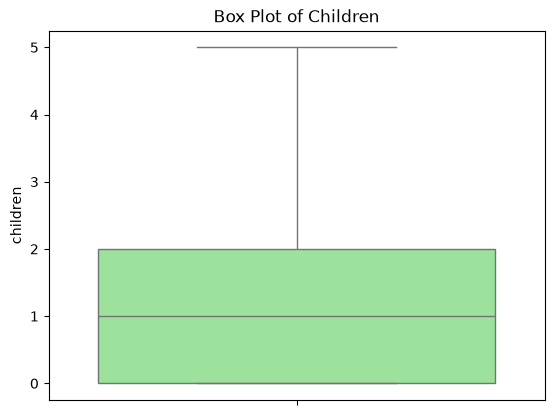

In [57]:
sns.boxplot(data=df, y='children', color='lightgreen')

plt.title('Box Plot of Children')

plt.show()

In [58]:
df['children'].skew()

np.float64(0.9402991133470963)

**Conclusion:**
- The histogram shows a discrete pattern rather then smooth curve. The data is right skewed most patients have 0-2 childerns very few have 4-5.
- The boxplot shows there is no outlier in childern data.

**`5. claim:`**

In [59]:
df['claim'].describe()

count     1340.000000
mean     13252.745642
std      12109.609288
min       1121.870000
25%       4719.685000
50%       9369.615000
75%      16604.305000
max      63770.430000
Name: claim, dtype: float64

iqr = 16604.305 - 4719.685 = 11884.62
lb = 
ub = 

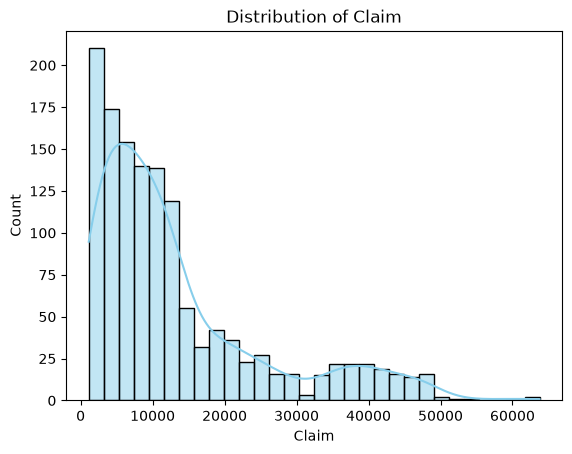

In [60]:
sns.histplot(data=df, x='claim', kde=True, color='skyblue')
plt.title('Distribution of Claim')
plt.xlabel('Claim')
plt.ylabel('Count')
plt.show()

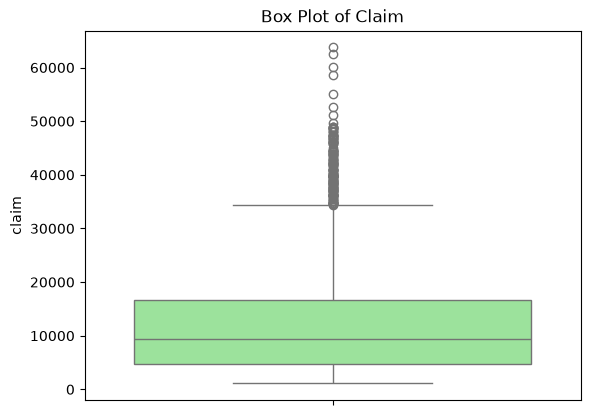

In [61]:
sns.boxplot(data=df, y='claim', color='lightgreen')

plt.title('Box Plot of Claim')

plt.show()

In [66]:
df[df['claim'] > 34431.235]

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1199,1199,1200,30.0,female,33.1,93,diabetic,0,smoker,southeast,34439.86
1200,1200,1201,40.0,male,32.7,98,non-diabetic,0,smoker,southwest,34472.84
1201,1201,1202,45.0,male,33.5,81,non-diabetic,0,smoker,northeast,34617.84
1202,1202,1203,32.0,male,31.7,125,non-diabetic,0,smoker,southeast,34672.15
1203,1203,1204,26.0,male,34.8,94,diabetic,0,smoker,southwest,34779.62
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,diabetic,0,smoker,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,non-diabetic,1,smoker,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,diabetic,3,smoker,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,non-diabetic,0,smoker,southeast,62592.87


In [62]:
df['claim'].skew()

np.float64(1.5167468509489237)

**Conclusions:**
- Claim is heavily right skewed with mean that is well above median indicating a subgroup of high cost outliers above ~34,431.

### `Categorical Columns:`

**`1. gender:`**

In [67]:
df['gender'].value_counts()

gender
male      678
female    662
Name: count, dtype: int64

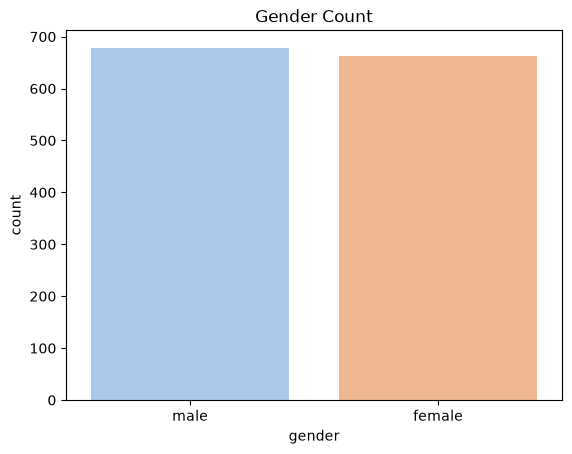

In [71]:
sns.countplot(data=df, x='gender', hue='gender', palette='pastel')
plt.title('Gender Count')
plt.show()

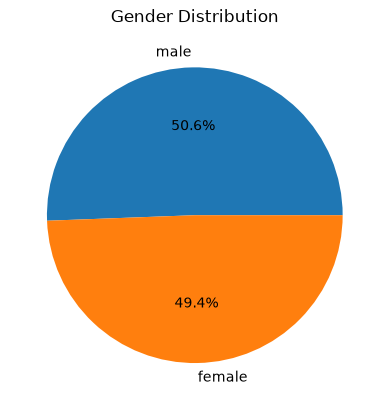

In [ ]:
data = df['gender'].value_counts()
plt.pie(data, labels=data.index, autopct='%0.1f%%')
plt.title('Gender Distribution')
plt.show()

In [89]:
df['gender'].isna().sum()

np.int64(0)

**Conclusion:**
- The gender data is almost equally distributed.
- There is no missing data in this col

**`2. diabetic:`**

In [80]:
df['diabetic'].value_counts()

diabetic
non-diabetic    698
diabetic        642
Name: count, dtype: int64

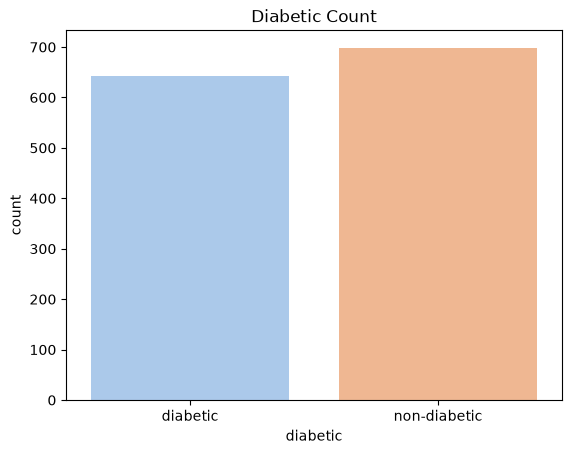

In [79]:
sns.countplot(data=df, x='diabetic', hue='diabetic', palette='pastel')
plt.title('Diabetic Count')
plt.show()

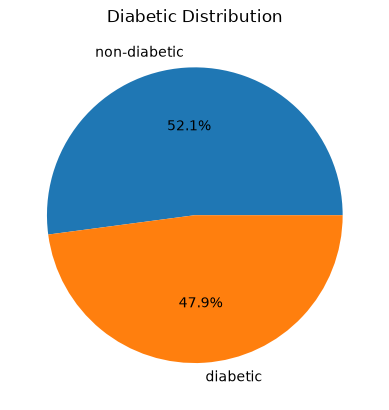

In [78]:
data = df['diabetic'].value_counts()
plt.pie(data, labels=data.index, autopct='%0.1f%%')
plt.title('Diabetic Distribution')
plt.show()

**Conclusion:**
- The dataset maintains a nearly balanced split with 52.1% non-diabetic and 47.9% diabetic policyholders.
- Almost half the sample has diabetes, making this a crucial health variable for predicting insurance claim costs.

**`3. smoker:`**

In [83]:
df['smoker'].value_counts()

smoker
non-smoker    1066
smoker         274
Name: count, dtype: int64

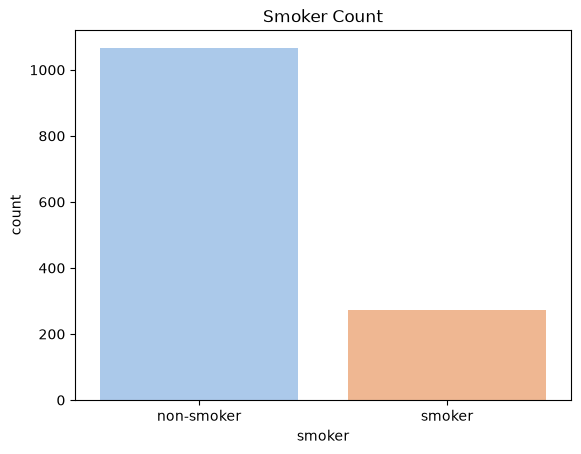

In [82]:
sns.countplot(data=df, x='smoker', hue='smoker', palette='pastel')
plt.title('Smoker Count')
plt.show()

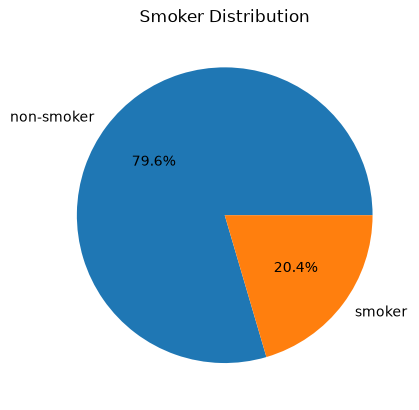

In [81]:
data = df['smoker'].value_counts()
plt.pie(data, labels=data.index, autopct='%0.1f%%')
plt.title('Smoker Distribution')
plt.show()

**Conclusion:**
- The dataset is heavily imbalanced, with non-smokers making up 79.6% (1,066) of entries and smokers accounting for only 20.4% (274).
- Although a minority group, smokers typically drive disproportionately high insurance claim costs in health datasets.

**`4. region:`**

In [84]:
df['region'].value_counts()

region
southeast    446
northwest    349
southwest    314
northeast    231
Name: count, dtype: int64

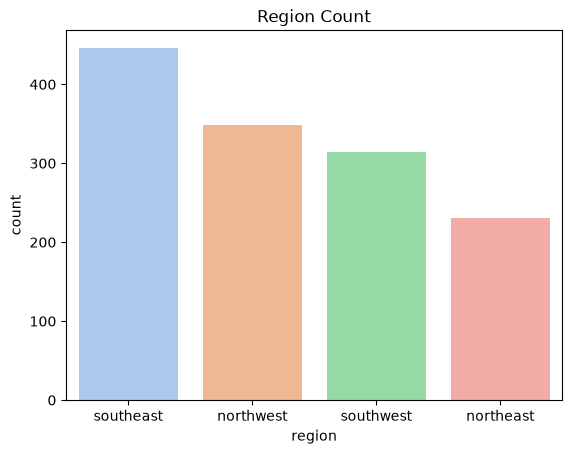

In [85]:
sns.countplot(data=df, x='region', hue='region', palette='pastel')
plt.title('Region Count')
plt.show()

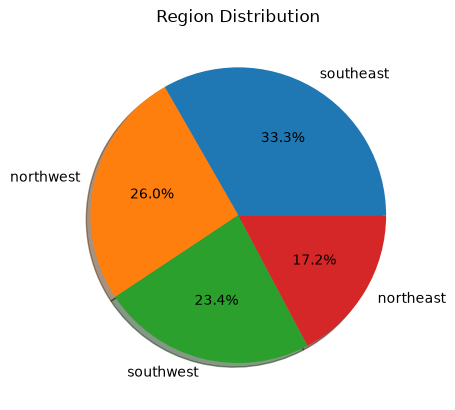

In [88]:
data = df['region'].value_counts()
plt.pie(data, labels=data.index, autopct='%0.1f%%', shadow=True)
plt.title('Region Distribution')
plt.show()

**Conclusion:**
- The southeast region has the highest representation at 33.3% (446), while the northeast has the lowest at 17.2% (231).